In [1]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
from pyearthtools.data.time import Petdt
from pyearthtools.pipeline.operations.xarray.join import GeospatialTimeSeriesMerge
import site_archive_nci

import shap

In [2]:
model = xgb.XGBRegressor()
# model.load_model("/scratch/er8/cd3022/xgb_models/test_model.json")
model.load_model("/scratch/er8/cd3022/xgb_models/radiance_model.json")

In [3]:
# data = pd.read_parquet('/scratch/er8/cd3022/xgb_datasets/syd_gridpoint_2024-01.parquet')
data = pd.read_parquet('/scratch/er8/cd3022/xgb_datasets/syd_radiances_2024-01-01.parquet')

In [4]:
X = data.drop(columns=['surface_global_irradiance'])
for n in range(1, 11):
    X = X.drop(columns=[f'surface_global_irradiance_t{n}'])

y = data['surface_global_irradiance_t3']

In [5]:
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

# # Convert back to DataFrame (keeps column names)
# X_scaled = pd.DataFrame(X_scaled, columns=data.columns, index=data.index)

In [6]:
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
importance = model.feature_importances_

feat_importance = pd.Series(importance, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=False)

print(feat_importance)

solar_elevation                        0.398931
channel_0003_scaled_radiance           0.337226
channel_0011_brightness_temperature    0.129011
channel_0013_brightness_temperature    0.064702
channel_0015_brightness_temperature    0.043323
channel_0008_brightness_temperature    0.017182
channel_0004_scaled_radiance           0.009625
dtype: float32


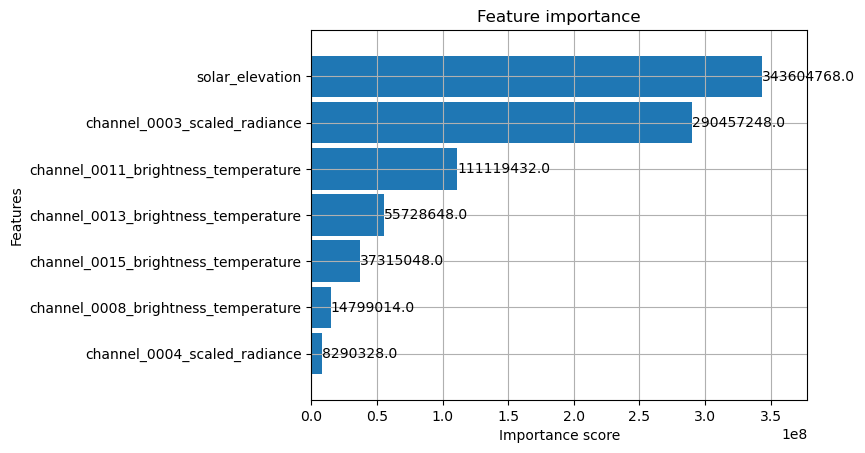

In [8]:
_ = xgb.plot_importance(model, height=0.9, importance_type="gain")

In [9]:
explainer = shap.Explainer(model)

idx = np.random.choice(len(X_test_scaled), size=2000, replace=False)
X_sample = X_test_scaled.iloc[idx]

shap_values = explainer(X_sample)

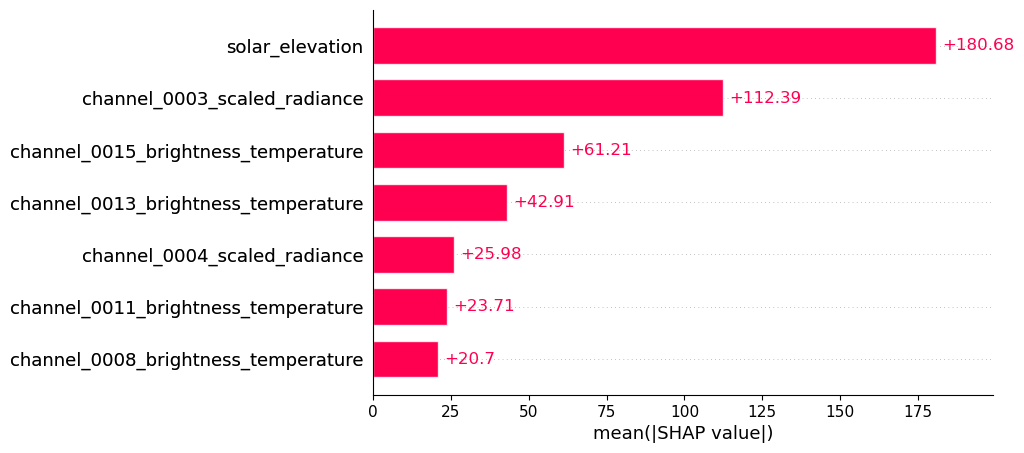

In [10]:
shap.plots.bar(shap_values)

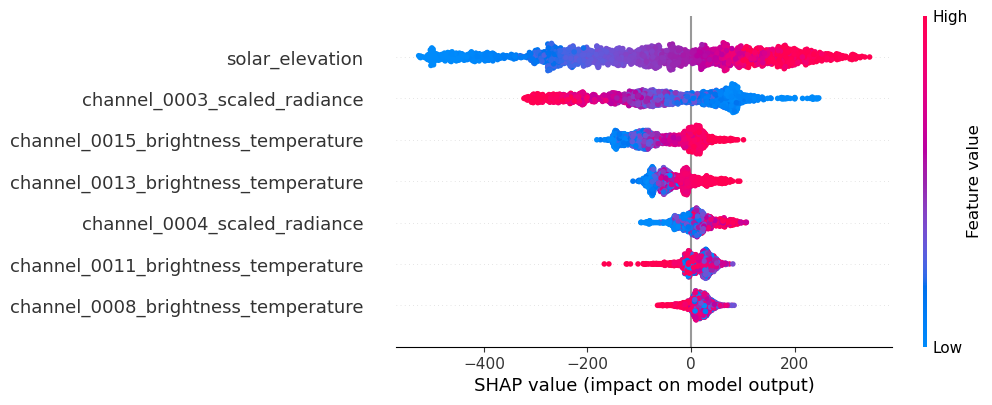

In [11]:
shap.plots.beeswarm(shap_values)

# Spatial Analysis